In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter

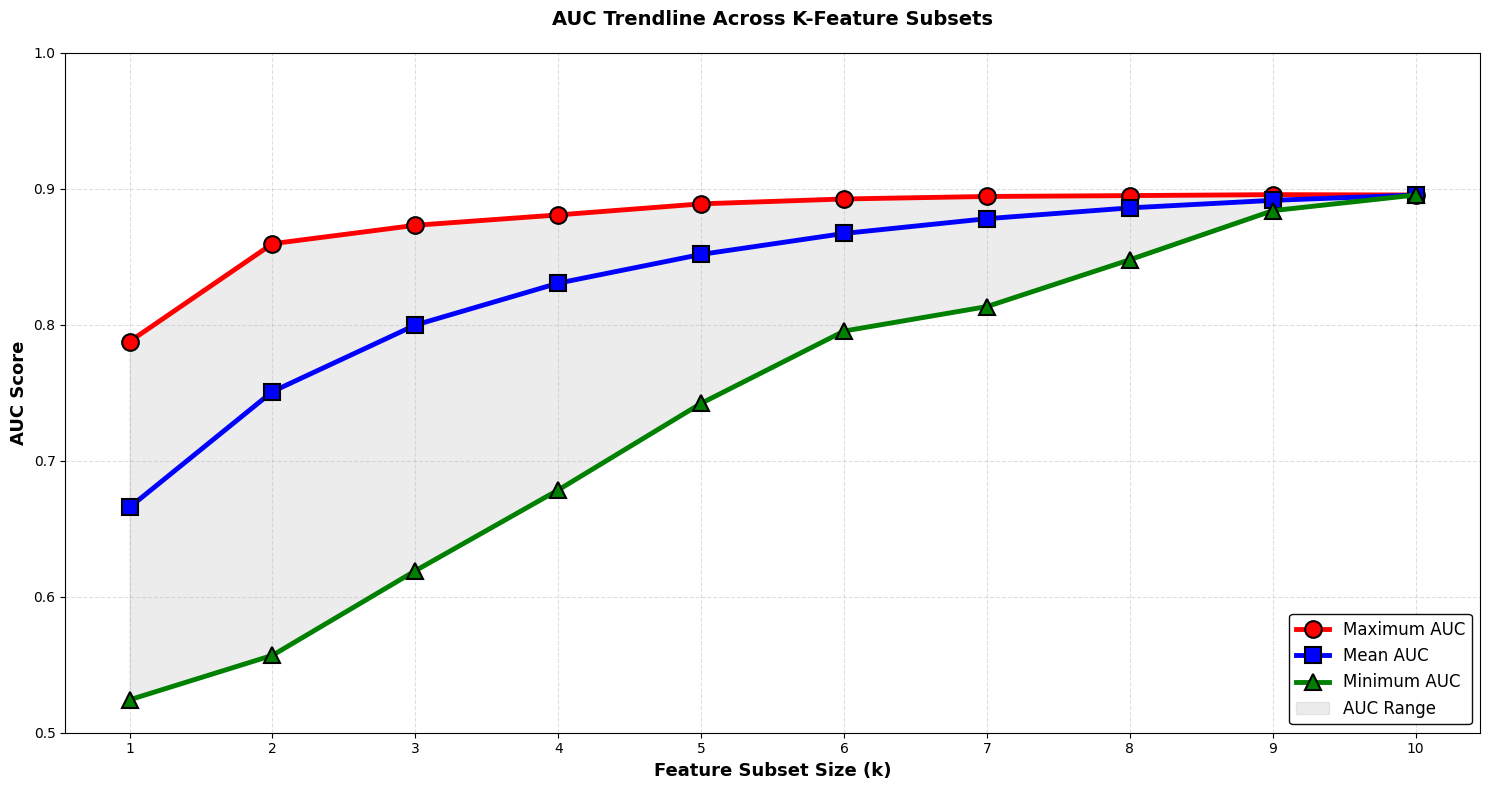

In [68]:
df = pd.read_csv('output.csv')
fig, ax = plt.subplots(figsize=(15, 8))
group_sizes = sorted(df['group_size'].unique())


max_auc_by_k = []
mean_auc_by_k = []
min_auc_by_k = []
for k in range(1, 11):
    max_auc_by_k.append(df[df['group_size'] == k]['auc'].max())
    mean_auc_by_k.append(df[df['group_size'] == k]['auc'].mean())
    min_auc_by_k.append(df[df['group_size'] == k]['auc'].min())

# Trend lines
ax.plot(
        group_sizes, max_auc_by_k, 
        marker='o', linewidth=3.5, markersize=12, label='Maximum AUC', 
        color='red', markeredgecolor='black', markeredgewidth=1.5
       )
ax.plot(
        group_sizes, mean_auc_by_k, 
        marker='s', linewidth=3.5, markersize=12, label='Mean AUC', 
        color='blue',  markeredgecolor='black', markeredgewidth=1.5
       )
ax.plot(
        group_sizes, min_auc_by_k, 
        marker='^', linewidth=3.5, markersize=12, label='Minimum AUC', 
        color='green', markeredgecolor='black', markeredgewidth=1.5
       )
ax.fill_between(
                group_sizes, min_auc_by_k, max_auc_by_k, 
                alpha=0.15, color='gray', label='AUC Range'
               )

#  Axes
ax.set_xlabel('Feature Subset Size (k)', fontsize=13, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=13, fontweight='bold')
ax.set_title('AUC Trendline Across K-Feature Subsets', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(group_sizes)
ax.set_xticklabels(group_sizes)
ax.grid(True, alpha=0.4, linestyle='--')
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=12, loc='lower right', framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.savefig('a1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

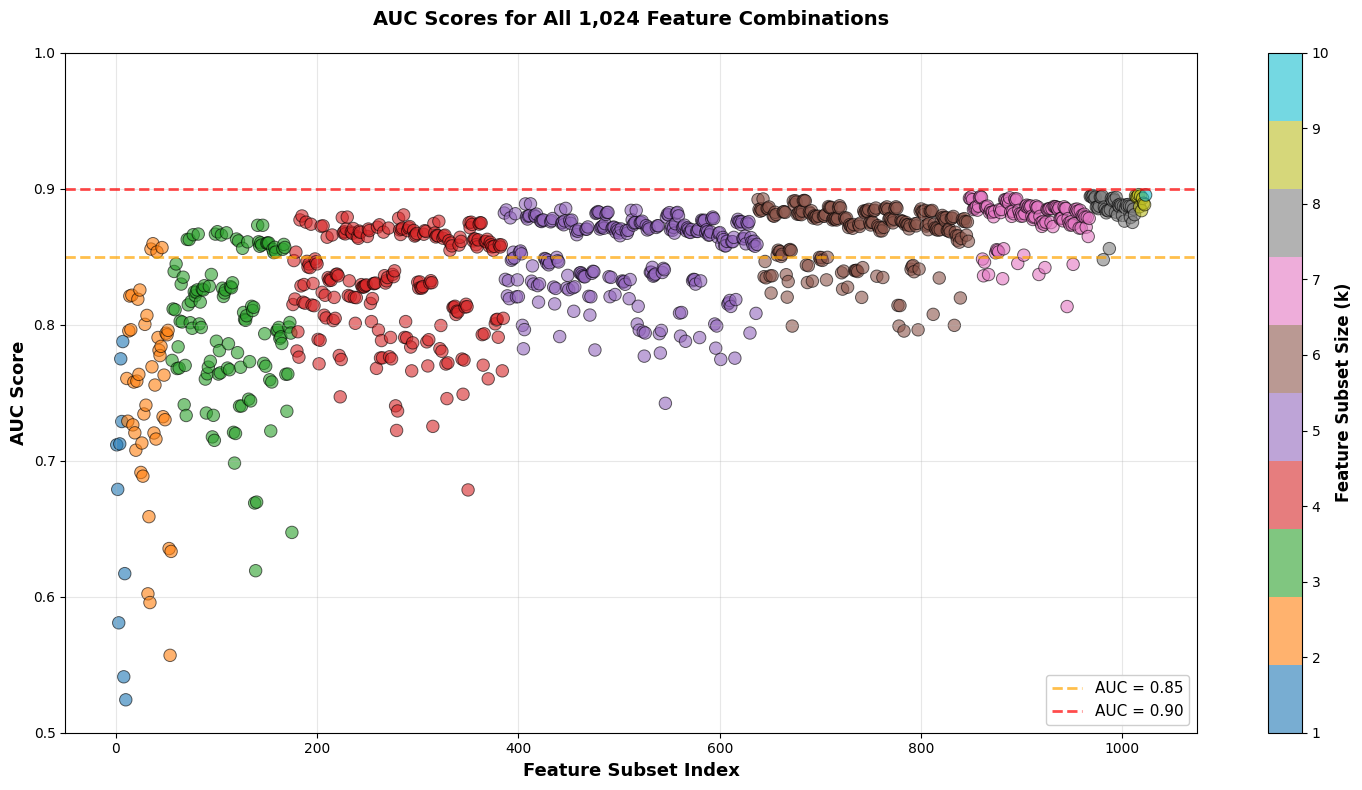

In [71]:
df = pd.read_csv('output.csv')
fig, ax = plt.subplots(figsize=(15, 8))
group_sizes = sorted(df['group_size'].unique())

scatter = ax.scatter(
                     df['run'], df['auc'], c=df['group_size'], 
                     cmap='tab10',s=80, alpha=0.6, 
                     edgecolors='black', linewidth=0.7
                    )

# Color bar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Feature Subset Size (k)', fontsize=12, fontweight='bold')
cbar.set_ticks(group_sizes)

# Thresholds
ax.axhline(y=0.85, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='AUC = 0.85')
ax.axhline(y=0.90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='AUC = 0.90')
ax.legend(fontsize=11, loc='lower right', framealpha=0.95)

# Axes
ax.set_xlabel('Feature Subset Index', fontsize=13, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=13, fontweight='bold')
ax.set_title('AUC Scores for All 1,024 Feature Combinations', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig('a2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

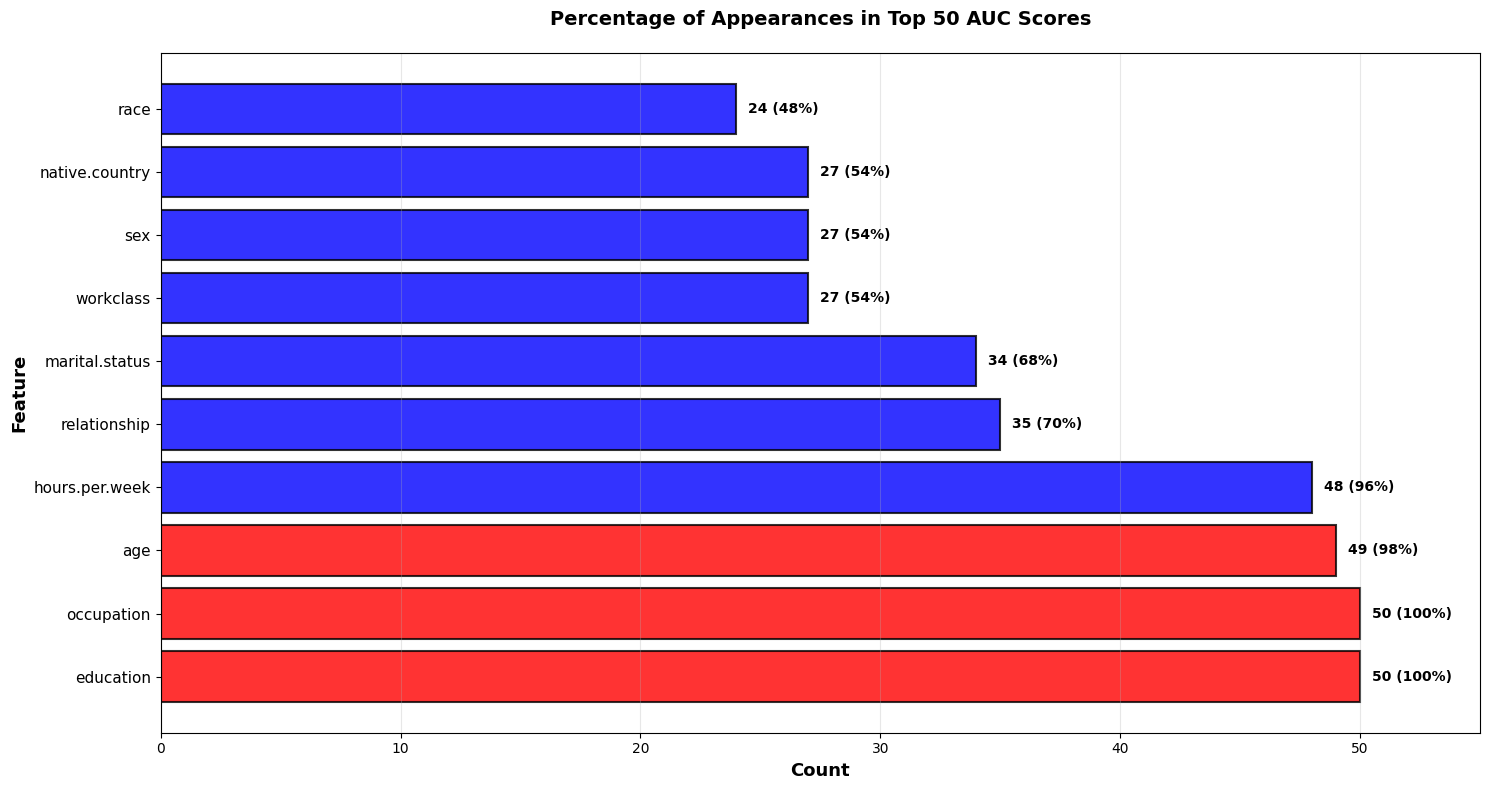

In [70]:
df = pd.read_csv('output.csv')
fig, ax = plt.subplots(figsize=(15, 8))
top_50 = df.nlargest(50, 'auc')

# One hot encoded vector -> feature
all_features = []
for groups_str in top_50['groups']:
    features_tuple = ast.literal_eval(groups_str)
    all_features.extend(features_tuple)
feature_counts = Counter(all_features)
sorted_features = feature_counts.most_common()
features = [f[0] for f in sorted_features]
counts = [f[1] for f in sorted_features]

# Highlight top 3
colors = ['Red' if i < 3 else 'Blue' for i in range(len(features))]
bars = ax.barh(
               range(len(features)), counts, color=colors, 
               edgecolor='black', linewidth=1.5, alpha=0.8
              )

# Axes
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel('Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Feature', fontsize=13, fontweight='bold')
ax.set_title('Percentage of Appearances in Top 50 AUC Scores', fontsize=14, fontweight='bold', pad=20)
ax.set_xlim([0, 55])
ax.grid(True, alpha=0.3, axis='x')

# Bar Labels
for i, (feature, count) in enumerate(zip(features, counts)):
    percentage = (count / 50) * 100
    ax.text(count + 0.5, i, f'{count} ({percentage:.0f}%)', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('a3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()